## ARIMAX

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import pickle

In [2]:
# Load merged data: prioritize CSV 'merged_data_final.csv', fallback to pickle or synthetic data for testing
import os
csv_path = '../data/processed/merged_data_final.csv'
data = pd.read_csv(csv_path, parse_dates=['datetime'])

# Ensure datetime is set as the time index
if 'datetime' in data.columns:
    data['datetime'] = pd.to_datetime(data['datetime'])
    data.set_index('datetime', inplace=True)

# Use 'close' as the target series
close_prices = data['close']

# Prepare exogenous variables. If missing, print warning and fill with 0 to ensure dimension consistency
exog_cols = ['roe_lag45d','ps_lag45d','de_ratio_lag45d','CAPEI_lag45d','bm_lag45d', 'avg_sentiment_neg_lag1d', 'avg_sentiment_neu_lag1d', 'avg_sentiment_pos_lag1d']
missing = [c for c in exog_cols if c not in data.columns]
if missing:
    print(f'Warning: The following exogenous variable columns are missing in the data and will be filled with 0: {missing}')
    for c in missing:
        data[c] = 0.0

# Construct exog DataFrame, ensuring correct order and alignment with close_prices
exog = data[exog_cols].astype(float)
# Simple check: length should match
assert len(exog) == len(close_prices), 'Exogenous variable length does not match target series length'

In [3]:
# Automatically select ARIMAX (with exogenous variables) parameters: use exog as the exogenous variable
# Note: the exogenous parameter name in auto_arima is 'exogenous'
model = auto_arima(close_prices, exogenous=exog, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=19904.558, Time=15.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=19971.055, Time=3.36 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=19915.095, Time=2.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=19915.165, Time=2.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=19971.514, Time=1.33 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=19912.288, Time=7.93 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=19919.078, Time=6.22 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=19907.878, Time=15.73 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=19904.938, Time=43.39 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=19917.024, Time=6.76 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=19905.320, Time=13.03 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=19911.987, Time=11.68 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=19906.373, Time=61.17 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=19905.164, Time=2.60 sec

Best model: 


==================== Close Price Stationarity Test Report ====================
ADF Statistic: -1.6411
p-value:       0.4617
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).


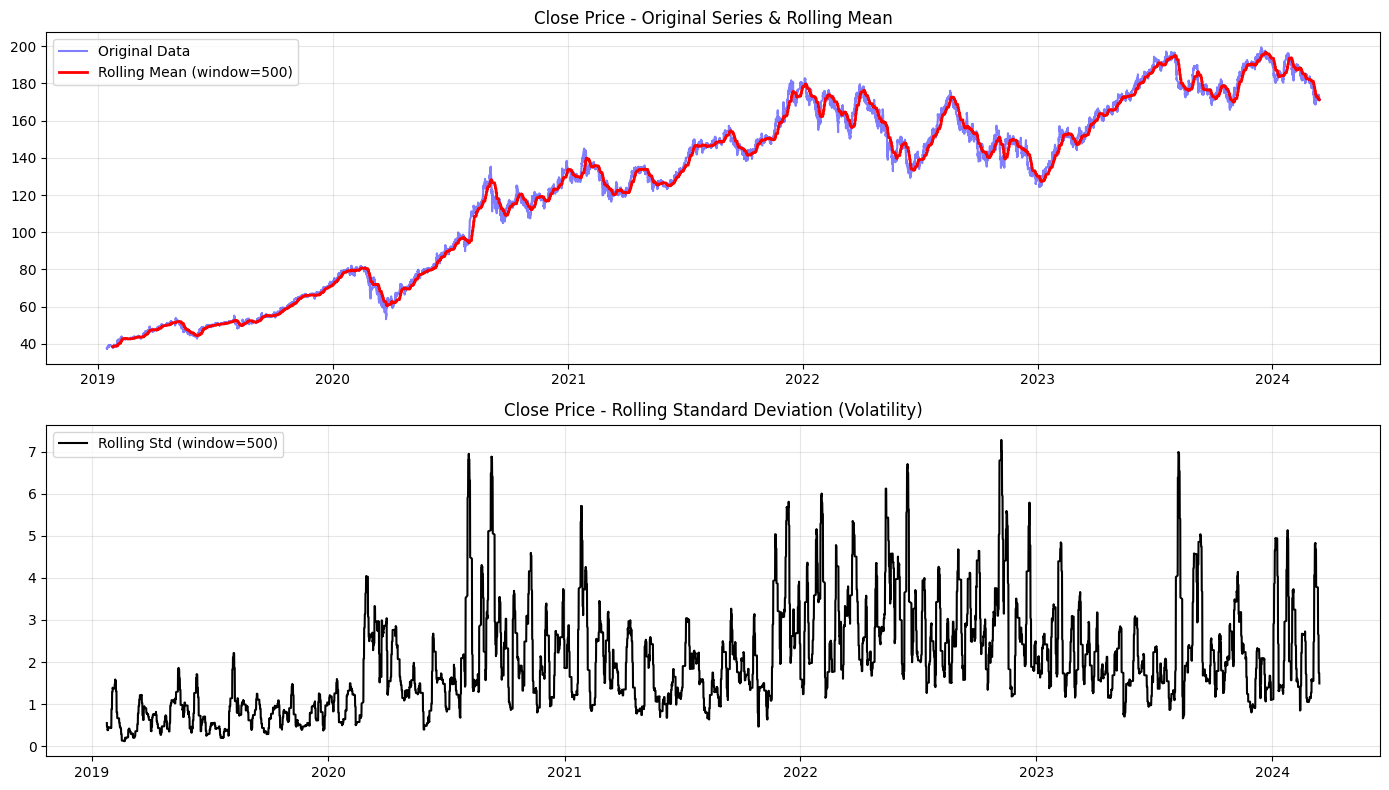


Original data detected as non-stationary, testing 1st Order Differenced data...

==================== 1st Order Differenced Close Price Stationarity Test Report ====================
ADF Statistic: -91.5038
p-value:       0.0000
Critical Values:
   1%: -3.4304
   5%: -2.8616
   10%: -2.5668
Conclusion: p-value < 0.05, the data is [STATIONARY].


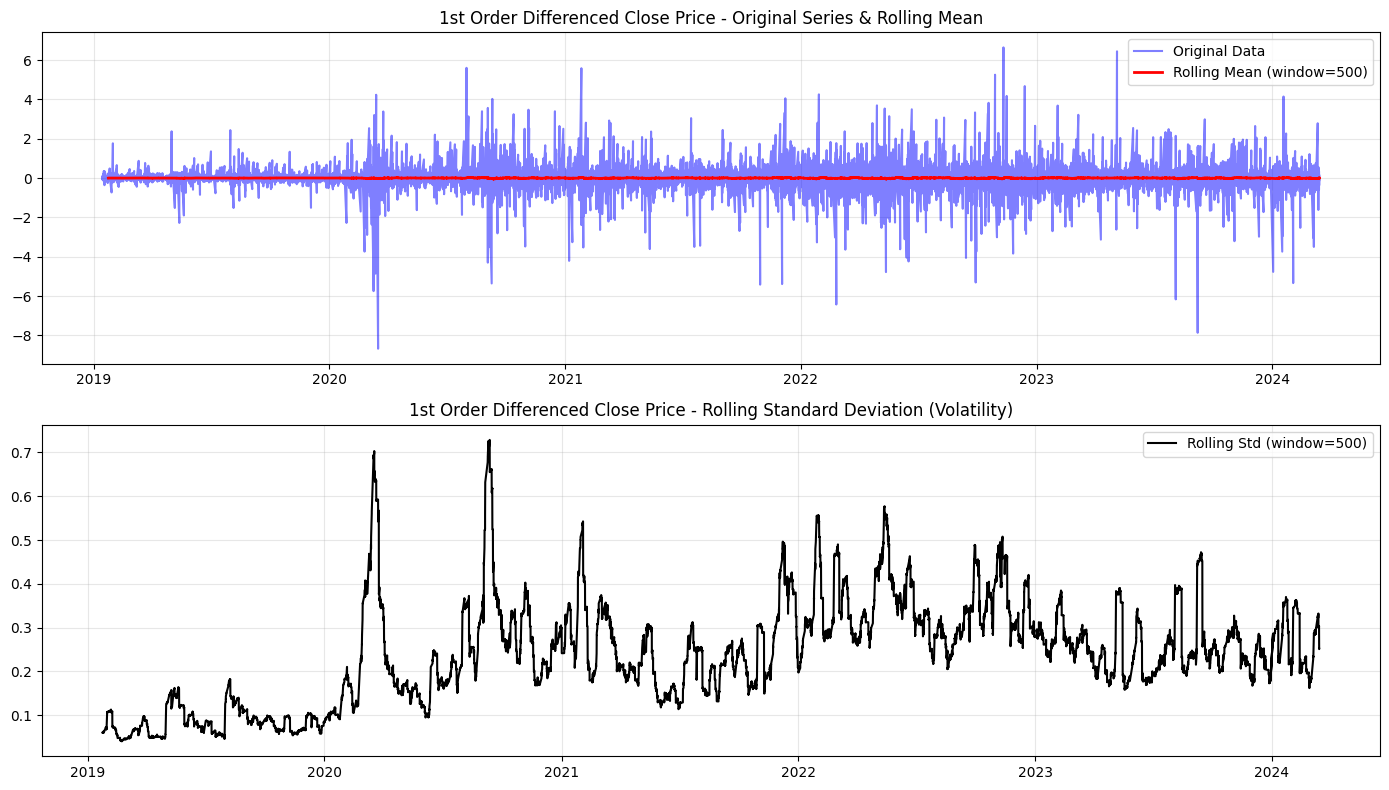


==================== Exogenous Variables Stationarity Overview ====================
Variable             | p-value    | Stationary?
---------------------------------------------
roe_lag45d           | 0.9038     | No
ps_lag45d            | 0.4260     | No
de_ratio_lag45d      | 0.6708     | No
CAPEI_lag45d         | 0.4149     | No
bm_lag45d            | 0.6805     | No
avg_sentiment_neg_lag1d | 0.0000     | Yes
avg_sentiment_neu_lag1d | 0.0000     | Yes
avg_sentiment_pos_lag1d | 0.0000     | Yes


In [4]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity_and_plot(series, title="Time Series", window_size=1000):
    """
    Performs the Augmented Dickey-Fuller (ADF) test and plots the stationarity analysis (Original Data vs Rolling Mean/Std Dev)
    """
    print(f"\n{'='*20} {title} Stationarity Test Report {'='*20}")
    
    # 1. ADF Statistical Test
    # Note: ADF cannot handle NaN, they must be removed
    clean_series = series.dropna()
    result = adfuller(clean_series)
    
    p_value = result[1]
    is_stationary = p_value < 0.05
    
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if is_stationary:
        print(f"Conclusion: p-value < 0.05, the data is [STATIONARY].")
    else:
        print(f"Conclusion: p-value >= 0.05, the data is [NON-STATIONARY] (trend or unit root exists).")

    # 2. Plotting Analysis
    plt.figure(figsize=(14, 8))
    
    # Top plot: Original data + Rolling Mean
    plt.subplot(2, 1, 1)
    plt.plot(series, label='Original Data', color='blue', alpha=0.5)
    # Calculate Rolling Mean and Rolling Standard Deviation
    rolmean = series.rolling(window=window_size).mean()
    rolstd = series.rolling(window=window_size).std()
    
    plt.plot(rolmean, label=f'Rolling Mean (window={window_size})', color='red', linewidth=2)
    plt.legend(loc='best')
    plt.title(f'{title} - Original Series & Rolling Mean')
    plt.grid(True, alpha=0.3)
    
    # Bottom plot: Rolling Standard Deviation (to check if volatility is stable)
    plt.subplot(2, 1, 2)
    plt.plot(rolstd, label=f'Rolling Std (window={window_size})', color='black')
    plt.legend(loc='best')
    plt.title(f'{title} - Rolling Standard Deviation (Volatility)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return is_stationary

# ==========================================
# Execution Code
# ==========================================

# 1. Test the Target Variable (Close Price)
# Original prices are typically non-stationary
is_close_stationary = check_stationarity_and_plot(close_prices, "Close Price", window_size=500)

# 2. If non-stationary, test the First Difference data
# This is what d=1 does in auto_arima
if not is_close_stationary:
    print("\nOriginal data detected as non-stationary, testing 1st Order Differenced data...")
    diff_series = close_prices.diff()
    check_stationarity_and_plot(diff_series, "1st Order Differenced Close Price", window_size=500)

# 3. (Optional) Quick check for Exogenous Variables
# ARIMAX preferably requires exogenous variables to be stationary. Print only text results to avoid excessive plots.
print(f"\n{'='*20} Exogenous Variables Stationarity Overview {'='*20}")
print(f"{'Variable':<20} | {'p-value':<10} | {'Stationary?'}")
print("-" * 45)

for col in exog_cols:
    clean_exog = data[col].dropna()
    res = adfuller(clean_exog)
    p_val = res[1]
    status = "Yes" if p_val < 0.05 else "No"
    print(f"{col:<20} | {p_val:.4f}     | {status}")

In [5]:
# Fit the ARIMAX model using the selected parameters (including exogenous variables exog)
order = model.order
# Pass exog into the model to construct ARIMAX
arima_model = ARIMA(close_prices, order=order, exog=exog)
arima_result = arima_model.fit()
print(arima_result.summary())

/Users/peterli/Library/Python/3.10/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/peterli/Library/Python/3.10/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/peterli/Library/Python/3.10/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               101860
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -9783.990
Date:                Sun, 23 Nov 2025   AIC                          19593.980
Time:                        00:17:56   BIC                          19717.887
Sample:                             0   HQIC                         19631.551
                             - 101860                                         
Covariance Type:                  opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
roe_lag45d                 -4.3711      0.182    -23.957      0.000      -4.729      -4.014
ps_lag45d                  -0.7105      0.040    -17.694      0.000      -0.789      -0.632


In [6]:
# Forecast future values (e.g., for the next 100 periods), with simple handling for exogenous variables: repeat the most recently observed exog values
forecast_steps = 100
# Create a time index for the future forecast (assuming 5-minute data interval)
last_datetime = close_prices.index[-1]
forecast_index = pd.date_range(start=last_datetime, periods=forecast_steps+1, freq='5min')[1:]  # Assuming 5-minute data

# Construct future exogenous variables: here we make a simple assumption—repeat the last observed exog value for 'forecast_steps' times
# A more robust approach would be to build separate forecasts for each exogenous variable, but that is outside the current modification scope
future_exog = pd.DataFrame([exog.iloc[-1].values] * forecast_steps, columns=exog.columns, index=forecast_index)

# Use arima_result.forecast by passing the future exog (for ARIMAX)
forecast = arima_result.forecast(steps=forecast_steps, exog=future_exog)

# For predictions on the test set (to compare with actual values), a corresponding exog slice must be provided
test_size = len(close_prices) - int(len(close_prices) * 0.8)
start_idx = len(close_prices) - test_size
end_idx = len(close_prices) - 1
exog_test_slice = exog.iloc[start_idx: end_idx + 1]
arima_test_forecast = arima_result.predict(start=start_idx, end=end_idx, exog=exog_test_slice)

# Combine actual values and forecasts for plotting
actual_series = close_prices
forecast_series = pd.Series(forecast.values, index=forecast_index)
arima_test_series = pd.Series(arima_test_forecast, index=close_prices.index[-test_size:])

/Users/peterli/Library/Python/3.10/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/peterli/Library/Python/3.10/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
# Evaluation Metrics (MSE, MAE, RMSE)

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Extract true test values and predicted test values
y_true = actual_series.iloc[start_idx: end_idx + 1]
y_pred = arima_test_series

# Ensure alignment (important for time series)
y_true, y_pred = y_true.align(y_pred, join='inner')

# Compute metrics
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print("\n==== Model Evaluation Metrics (Test Set) ====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


==== Model Evaluation Metrics (Test Set) ====
MSE : 0.0670
MAE : 0.1524
RMSE: 0.2588


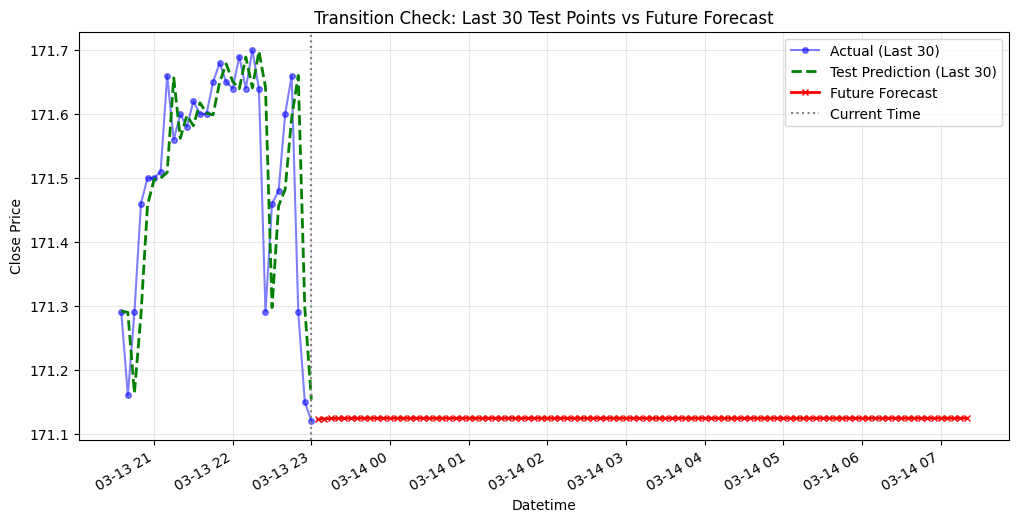

In [8]:
# Set the size of the focused window
window_size = 30

plt.figure(figsize=(12, 6))

# 1. Plot the last 30 actual values (as the baseline reference)
# Use .tail(window_size) to automatically get the last 30 points
plt.plot(close_prices.index[-window_size:], 
         close_prices.tail(window_size), 
         label='Actual (Last 30)', color='blue', marker='o', markersize=4, alpha=0.5)

# 2. Plot the last 30 test set predictions (to see model performance at the end of known data)
# Assuming arima_test_series is long enough, take the last 30 points
if len(arima_test_series) >= window_size:
    plt.plot(arima_test_series.index[-window_size:], 
             arima_test_series.tail(window_size), 
             label='Test Prediction (Last 30)', color='green', linestyle='--', linewidth=2)

# 3. Plot the future forecast (all points)
plt.plot(forecast_series.index, 
         forecast_series, 
         label='Future Forecast', color='red', marker='x', markersize=4, linewidth=2)

# Add a vertical line to mark the 'current time' boundary
last_date = close_prices.index[-1]
plt.axvline(x=last_date, color='gray', linestyle=':', label='Current Time')

plt.title(f'Transition Check: Last {window_size} Test Points vs Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Automatically rotate date labels to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

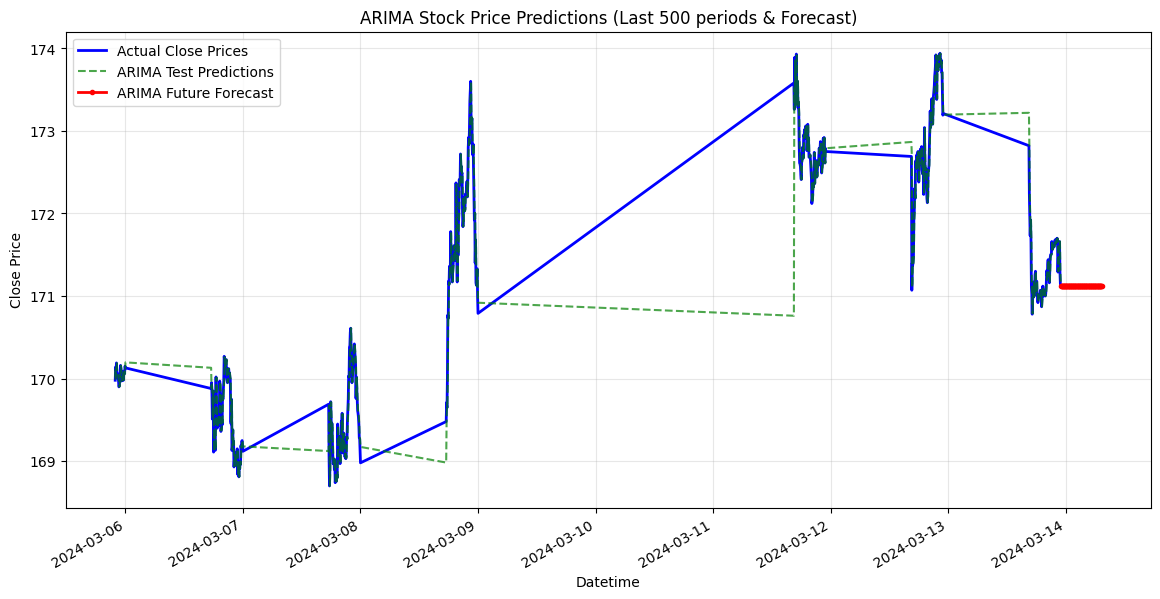

In [9]:
# Set the display window size (e.g., only show the last 500 points + future forecast)
zoom_window = 500 

plt.figure(figsize=(14, 7))

# 1. Plot historical data (only take the last zoom_window points)
# Use .tail() to slice the end
plt.plot(close_prices.index[-zoom_window:], 
         close_prices.tail(zoom_window), 
         label='Actual Close Prices', color='blue', linewidth=2)

# 2. Plot test set predictions (if there is overlap, only take the most recent)
# Ensure the index is within the zoom_window range before displaying
subset_test = arima_test_series[arima_test_series.index >= close_prices.index[-zoom_window]]
if not subset_test.empty:
    plt.plot(subset_test.index, subset_test, 
             label='ARIMA Test Predictions', color='green', linestyle='--', alpha=0.7)

# 3. Plot future forecast (this is the part you just created, plot all points)
plt.plot(forecast_series.index, forecast_series, 
         label='ARIMA Future Forecast', color='red', marker='.', linestyle='-', linewidth=2)

plt.title(f'ARIMA Stock Price Predictions (Last {zoom_window} periods & Forecast)')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Optimize X-axis time display to prevent overlap
plt.gcf().autofmt_xdate()

plt.show()

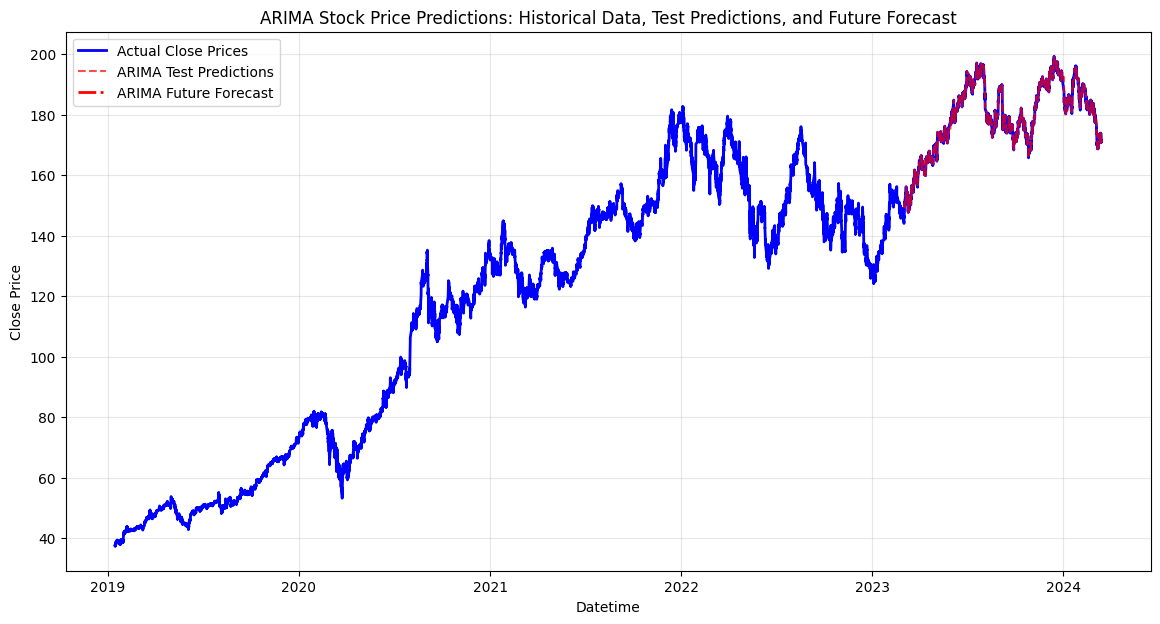

In [10]:
# Plot ARIMA predictions: historical data, test predictions, and future forecast
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(arima_test_series.index, arima_test_series, label='ARIMA Test Predictions', color='red', linestyle='--', alpha=0.7)
plt.plot(forecast_series.index, forecast_series, label='ARIMA Future Forecast', color='red', linestyle='-.', linewidth=2)
plt.title('ARIMA Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM

In [11]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from sklearn.preprocessing import StandardScaler
from src.train import create_sequences, train_lstm, predict_lstm
from src.model import LSTMModel
import torch
from torch.utils.data import DataLoader, TensorDataset



# Prepare data for LSTM
raw_train_size = int(len(close_prices) * 0.8)
train_data_raw = close_prices.iloc[:raw_train_size].values.reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(train_data_raw) 

scaled_data = scaler.transform(close_prices.values.reshape(-1, 1))

seq_length = 60  # Use 60 time steps (5 hours of 5-min data)
X, y = create_sequences(scaled_data, seq_length)

# Split into train and test
train_split_idx = raw_train_size - seq_length

if train_split_idx < 0:
    raise ValueError("Not enough data to create sequences of the specified length.")

X_train, X_test = X[:train_split_idx], X[train_split_idx:]
y_train, y_test = y[:train_split_idx], y[train_split_idx:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data prepared. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Scaler used: StandardScaler (Mean: {scaler.mean_[0]:.2f}, Scale: {scaler.scale_[0]:.2f})")


model = LSTMModel()
model = train_lstm(model, train_loader, num_epochs=50, lr=0.001)
forecast_steps = 100

test_predictions, future_predictions = predict_lstm(
    model, 
    X_test, 
    scaled_data, 
    scaler, 
    seq_length, 
    forecast_steps
)

# Create forecast series for LSTM
last_timestamp = close_prices.index[-1]
lstm_forecast_index = pd.date_range(start=last_timestamp, periods=forecast_steps+1, freq='5min')[1:]
lstm_forecast_series = pd.Series(future_predictions.flatten(), index=lstm_forecast_index)

lstm_test_index = close_prices.index[raw_train_size : raw_train_size + len(test_predictions)]
lstm_test_series = pd.Series(test_predictions.flatten(), index=lstm_test_index)

print("Predictions and forecasting completed.")

Data prepared. Train shape: torch.Size([81428, 60, 1]), Test shape: torch.Size([20372, 60, 1])
Scaler used: StandardScaler (Mean: 112.77, Scale: 42.50)
Starting LSTM training...
LSTM Epoch [10/50], Loss: 0.00041359
LSTM Epoch [20/50], Loss: 0.00004802
LSTM Epoch [30/50], Loss: 0.00014798
LSTM Epoch [40/50], Loss: 0.00009454
LSTM Epoch [50/50], Loss: 0.00008382
LSTM Training completed.
Predictions and forecasting completed.


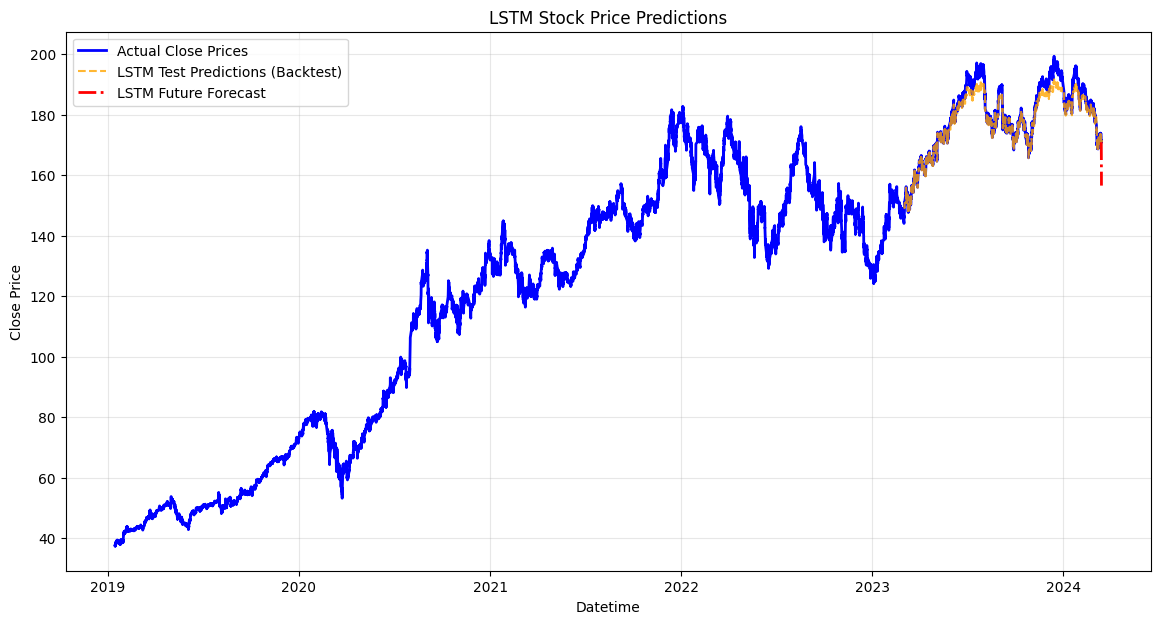

In [12]:
# Plot LSTM predictions
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index, close_prices, label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index, lstm_test_series, label='LSTM Test Predictions (Backtest)', color='orange', linestyle='--', alpha=0.8)
plt.plot(lstm_forecast_series.index, lstm_forecast_series, label='LSTM Future Forecast', color='red', linestyle='-.', linewidth=2)

plt.title('LSTM Stock Price Predictions')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

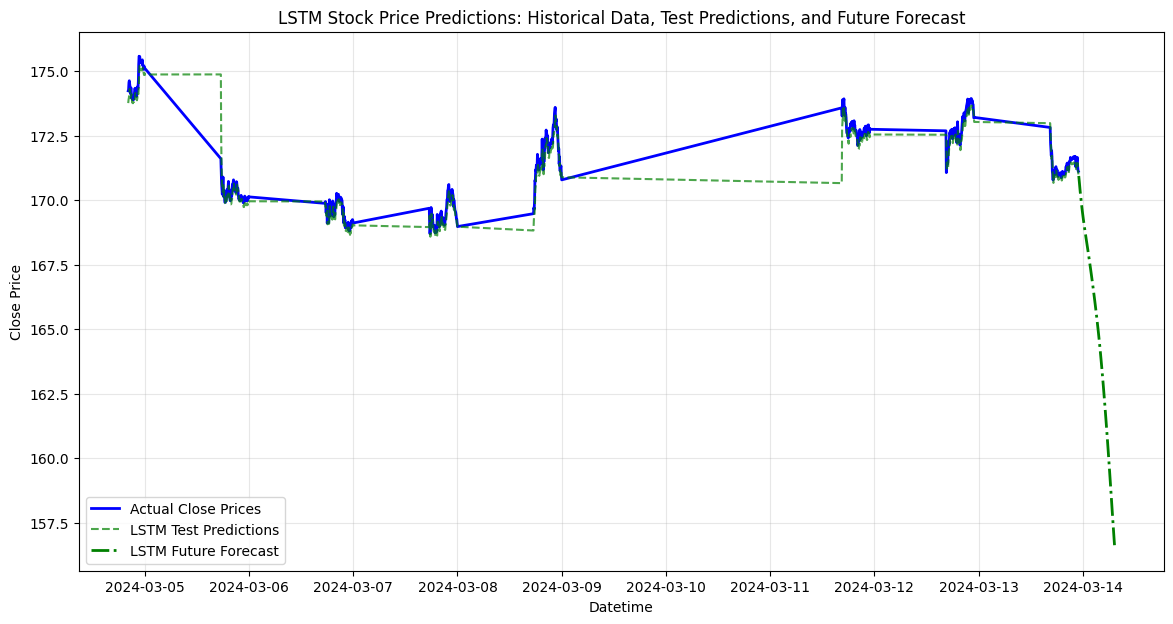

In [13]:
# Plot LSTM predictions: historical data, test predictions, and future forecast
last_n = 600
plt.figure(figsize=(14, 7))
plt.plot(close_prices.index[-last_n:], close_prices.iloc[-last_n:], label='Actual Close Prices', color='blue', linewidth=2)
plt.plot(lstm_test_series.index[-last_n:], lstm_test_series[-last_n:], label='LSTM Test Predictions', color='green', linestyle='--', alpha=0.7)
plt.plot(lstm_forecast_series.index[-last_n:], lstm_forecast_series[-last_n:], label='LSTM Future Forecast', color='green', linestyle='-.', linewidth=2)
plt.title('LSTM Stock Price Predictions: Historical Data, Test Predictions, and Future Forecast')
plt.xlabel('Datetime')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM-MLP

In [14]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import torch
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from src.model import LSTMModel, MLPModel
from src.train import train_lstm, train_mlp, create_sequences, run_hybrid_forecast
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
# Preprocessing (LSTM)
# Split sizes
raw_train_size = int(len(close_prices) * 0.8)

# Scale Close Prices (Target)
scaler_price = StandardScaler()
train_data_raw = close_prices.iloc[:raw_train_size].values.reshape(-1, 1)
scaler_price.fit(train_data_raw)
scaled_close = scaler_price.transform(close_prices.values.reshape(-1, 1))

# Scale Exogenous Variables (Important for MLP)
scaler_exog = StandardScaler()
train_exog_raw = exog.iloc[:raw_train_size].values
scaler_exog.fit(train_exog_raw)
scaled_exog = scaler_exog.transform(exog.values)

# Create LSTM Sequences
seq_length = 60
X_lstm, y_lstm = create_sequences(scaled_close, seq_length)

# Prepare LSTM Train Data
train_split_idx = raw_train_size - seq_length
if train_split_idx < 0: raise ValueError("Not enough data.")

X_train_lstm = torch.tensor(X_lstm[:train_split_idx], dtype=torch.float32)
y_train_lstm = torch.tensor(y_lstm[:train_split_idx], dtype=torch.float32)

lstm_loader = DataLoader(TensorDataset(X_train_lstm, y_train_lstm), batch_size=32, shuffle=True)

In [16]:
# Train LSTM
lstm_model = LSTMModel(dropout=0.2) 
lstm_model = train_lstm(lstm_model, lstm_loader, num_epochs=20, lr=0.001)

Starting LSTM training...
LSTM Epoch [10/20], Loss: 0.00018123
LSTM Epoch [20/20], Loss: 0.00018956
LSTM Training completed.


In [17]:
# We need to run the LSTM on the existing data to get its "base predictions"
# These base predictions + exog vars will be the input to the MLP.

lstm_model.eval()
with torch.no_grad():
    # Get LSTM predictions for the ENTIRE dataset available for creating sequences
    # Input X_lstm covers data from index 0 to N-1
    # Prediction corresponds to index seq_length to N
    all_lstm_inputs = torch.tensor(X_lstm, dtype=torch.float32)
    lstm_outputs = lstm_model(all_lstm_inputs) # Shape: [N_samples, 1]

# Align Exogenous Features with LSTM Outputs
# X_lstm[i] uses data from i to i+seq_length. The label is at i+seq_length.
# So the Exog data should also be taken from i+seq_length.
aligned_exog = scaled_exog[seq_length:] 

# Truncate to match lengths (just in case)
min_len = min(len(lstm_outputs), len(aligned_exog))
lstm_outputs = lstm_outputs[:min_len]
aligned_exog_tensor = torch.tensor(aligned_exog[:min_len], dtype=torch.float32)

# Concatenate [LSTM_Pred, Exog_Vars]
X_mlp = torch.cat((lstm_outputs, aligned_exog_tensor), dim=1) 
# Target for MLP is the actual scaled close price at that time
y_mlp = torch.tensor(scaled_close[seq_length:seq_length+min_len], dtype=torch.float32)

# Split MLP Data (Train/Test)
# We use the same split index logic, but adjusted for the sequence offset
mlp_train_size = train_split_idx 

# Train Set
X_train_mlp = X_mlp[:mlp_train_size]
y_train_mlp = y_mlp[:mlp_train_size]

# Test Set (For Evaluation)
X_test_mlp = X_mlp[mlp_train_size:]
y_test_mlp = y_mlp[mlp_train_size:]

mlp_loader = DataLoader(TensorDataset(X_train_mlp, y_train_mlp), batch_size=32, shuffle=True)

print(f"MLP Data Prepared. Input Features: {X_mlp.shape[1]} (1 LSTM + {aligned_exog.shape[1]} Exog)")
print(f"MLP Train Size: {len(X_train_mlp)}, MLP Test Size: {len(X_test_mlp)}")

MLP Data Prepared. Input Features: 9 (1 LSTM + 8 Exog)
MLP Train Size: 81428, MLP Test Size: 20372


In [18]:
#Train MLP
# Input size = 1 (LSTM pred) + Number of Exog columns
mlp_input_size = 1 + exog.shape[1]
mlp_model = MLPModel(input_size=mlp_input_size, hidden_size1=64, hidden_size2=32)

mlp_model = train_mlp(mlp_model, mlp_loader, num_epochs=20, lr=0.001)

Starting MLP training...
MLP Epoch [10/20], Loss: 0.00004567
MLP Epoch [20/20], Loss: 0.00005436
MLP Training completed.


In [19]:
# Model Evaluation on Test Set
mlp_model.eval()
with torch.no_grad():
    # Predict on the MLP Test Set
    test_preds_scaled = mlp_model(X_test_mlp).numpy()

# Inverse transform to get actual prices (Un-scaled)
test_preds_actual = scaler_price.inverse_transform(test_preds_scaled)
y_test_actual = scaler_price.inverse_transform(y_test_mlp.reshape(-1, 1).numpy())

# Calculate Metrics
mse = mean_squared_error(y_test_actual, test_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_preds_actual)

print("\n==== Model Evaluation Metrics (Test Set) ====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")



==== Model Evaluation Metrics (Test Set) ====
MSE : 10.0336
MAE : 1.8289
RMSE: 3.1676


In [20]:
# Hybrid Forecasting (Future 100 Steps)
forecast_steps = 100

# Injecting noise to prevent "straight line" forecast
hybrid_predictions = run_hybrid_forecast(
    lstm_model,
    mlp_model,
    scaled_close,
    scaled_exog,
    scaler_price,
    scaler_exog,
    seq_length,
    forecast_steps,
    noise_level=0.01  # Adjust this to control volatility (0.01 - 0.1 is usually good)
)

# Create Pandas Series for plotting
last_timestamp = close_prices.index[-1]
forecast_index = pd.date_range(start=last_timestamp, periods=forecast_steps+1, freq='5min')[1:]
forecast_series = pd.Series(hybrid_predictions.flatten(), index=forecast_index)

print("Hybrid Forecasting completed.")
print(forecast_series)

Hybrid Forecasting completed.
2024-03-13 23:05:00    171.490503
2024-03-13 23:10:00    171.678182
2024-03-13 23:15:00    171.477593
2024-03-13 23:20:00    171.622527
2024-03-13 23:25:00    171.902586
                          ...    
2024-03-14 07:00:00    182.320138
2024-03-14 07:05:00    182.479559
2024-03-14 07:10:00    182.279263
2024-03-14 07:15:00    182.149099
2024-03-14 07:20:00    182.274242
Freq: 5T, Length: 100, dtype: float64


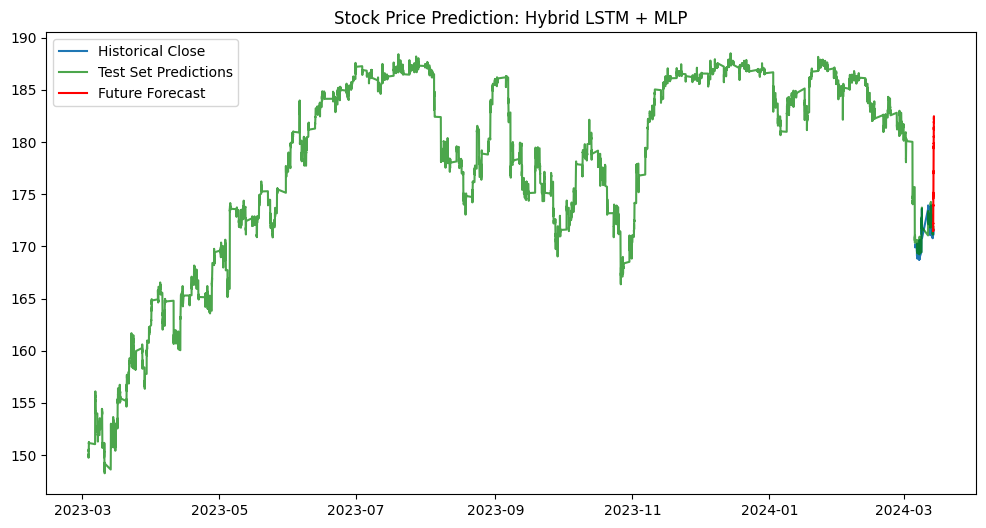

In [21]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(close_prices.index[-500:], close_prices.values[-500:], label='Historical Close')
# Plot test set predictions for visual validation
test_index_plot = close_prices.index[seq_length + mlp_train_size : seq_length + mlp_train_size + len(test_preds_actual)]
if len(test_index_plot) == len(test_preds_actual):
     plt.plot(test_index_plot, test_preds_actual, label='Test Set Predictions', color='green', alpha=0.7)

plt.plot(forecast_series.index, forecast_series.values, label='Future Forecast', color='red')
plt.legend()
plt.title("Stock Price Prediction: Hybrid LSTM + MLP")
plt.show()

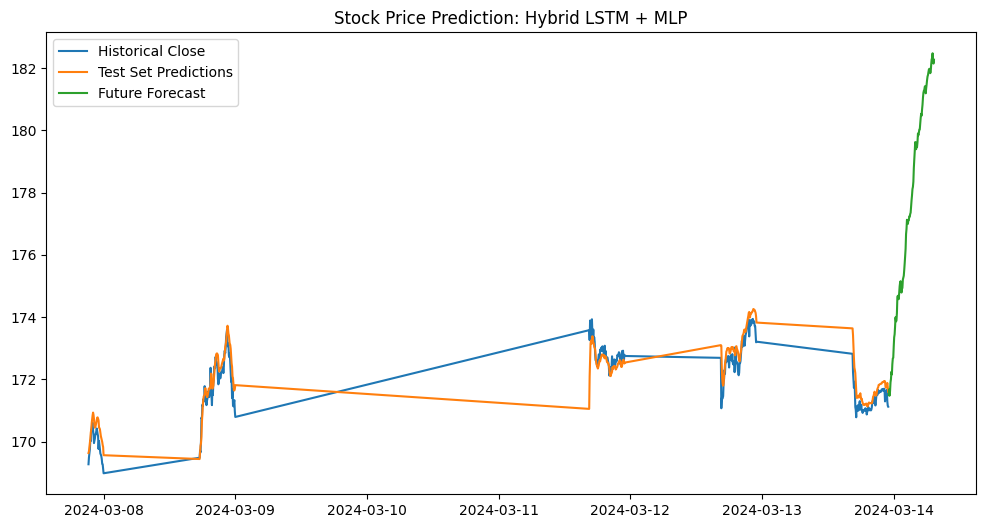

In [22]:
N = 350  # 想显示的最后数据数量

plt.figure(figsize=(12, 6))

# Historical
plt.plot(close_prices.index[-N:], close_prices.values[-N:], label='Historical Close')

# Test predictions
test_index_plot = close_prices.index[seq_length + mlp_train_size : seq_length + mlp_train_size + len(test_preds_actual)]
if len(test_index_plot) == len(test_preds_actual):
    # 同样只显示最后 N 的部分
    plt.plot(test_index_plot[-N:], test_preds_actual[-N:], label='Test Set Predictions')

# Future forecast
plt.plot(forecast_series.index[-N:], forecast_series.values[-N:], label='Future Forecast')

plt.legend()
plt.title("Stock Price Prediction: Hybrid LSTM + MLP")
plt.show()